<a href="https://colab.research.google.com/github/MariamF35/IoT-Based-Heart-Rate-Monitoring-and-Arrhythmia-Detection-Using-ESP32-and-ML/blob/main/IoT_Based_Heart_Rate_Monitoring_and_Arrhythmia_Detection_Using_ESP32_and_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# pip install commands
!pip install requests wfdb numpy pandas matplotlib scikit-learn tensorflow

In [2]:
#import statements
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [22]:
#Loading MIT-BIH dataset

records = [
'100','101','102','103','104','105','106','107','108','109',
'111','112','113','114','115','116','117','118','119','121',
'122','123','124','200','201','202','203','205','207','208',
'209','210','212','213','214','215','217','219','220','221',
'222','223','228','230','231','232','233','234'
]

signals = []
labels = []

window_size = 180

In [23]:
#Extract ECG heartbeats

for record in records:

    signal, fields = wfdb.rdsamp(record, pn_dir='mitdb')
    annotation = wfdb.rdann(record, 'atr', pn_dir='mitdb')

    for i in range(len(annotation.sample)):

        pos = annotation.sample[i]
        label = annotation.symbol[i]

        start = pos - window_size//2
        end = pos + window_size//2

        if start > 0 and end < len(signal):

            beat = signal[start:end,0]

            signals.append(beat)
            labels.append(label)

signals = np.array(signals)
labels = np.array(labels)

print("Dataset shape:", signals.shape)

Dataset shape: (112579, 180)


In [24]:
#converting heart beat numbers to labels

encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)

labels_cat = to_categorical(labels_encoded)

In [25]:
#Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    signals,
    labels_cat,
    test_size=0.2,
    random_state=42
)

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape)

(90063, 180, 1)


In [26]:
#building CNN model
model = Sequential()

model.add(Conv1D(32,5,activation='relu',input_shape=(180,1)))
model.add(MaxPooling1D(2))

model.add(Conv1D(64,5,activation='relu'))
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(labels_cat.shape[1],activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 176, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 88, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 84, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 42, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2688)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       344,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,655 (1.36 MB)

 Trainable params: 357,655 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
#Training the model

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test,y_test)
)

Epoch 1/10
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.8977 - loss: 0.4172 - val_accuracy: 0.9509 - val_loss: 0.1775
Epoch 2/10
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.9453 - loss: 0.2100 - val_accuracy: 0.9582 - val_loss: 0.1467
Epoch 3/10
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.9543 - loss: 0.1728 - val_accuracy: 0.9663 - val_loss: 0.1169
Epoch 4/10
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.9583 - loss: 0.1513 - val_accuracy: 0.9708 - val_loss: 0.1096
Epoch 5/10
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 46s 32ms/step - accuracy: 0.9619 - loss: 0.1387 - val_accuracy: 0.9722 - val_loss: 0.1030
Epoch 6/10
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 79s 31ms/step - accuracy: 0.9647 - loss: 0.1277 - val_accuracy: 0.9734 - val_loss: 0.0964
Epoch 7/10
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9670 - loss: 0.1182 - val_accuracy: 0.9753 - val_loss: 0.0903
Epoch 8/10
1408/1408 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.9681 -

In [28]:
#Evaluating the model

loss, accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:", accuracy)

704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9766 - loss: 0.0846
Test Accuracy: 0.9766388535499573


In [29]:
#Saving model
model.save("arrhythmia_model.h5")

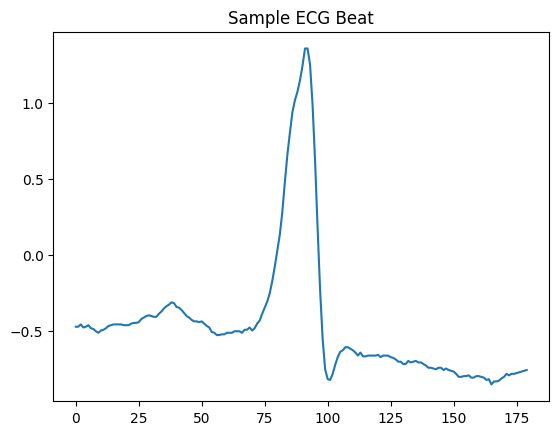

In [30]:
#Graphical reseprsentation

plt.plot(X_test[0])
plt.title("Sample ECG Beat")
plt.show()

In [3]:
import requests
import pandas as pd

CHANNEL_ID = "3251374"
#QWZ8LZUO5AIA84RE
READ_API = "QWZ8LZUO5AIA84RE"

url = f"https://api.thingspeak.com/channels/{CHANNEL_ID}/feeds.json?api_key={READ_API}&results=50"

data = requests.get(url).json()

bpm_values = [float(feed["field1"]) for feed in data["feeds"] if feed["field1"]]

print(bpm_values)

[199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 199.0, 1.0, 197.0, 199.0, 199.0, 2.0]


In [4]:
#Arrhythmia detection

bpm = np.array(bpm_values)

if np.std(bpm) > 15:
    print("⚠️ Possible Arrhythmia Detected")
else:
    print("Normal Heart Rhythm")

⚠️ Possible Arrhythmia Detected


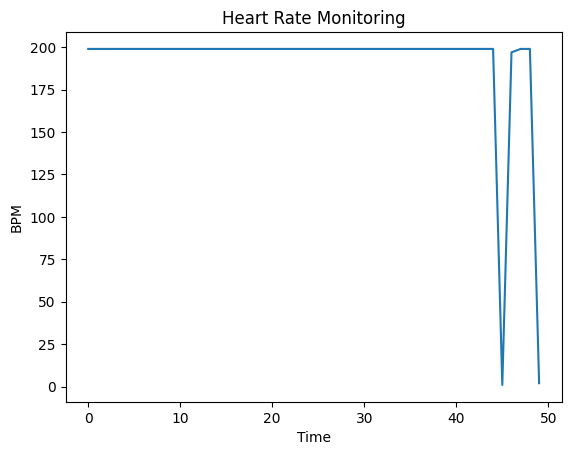

In [5]:
#Plotting graph

plt.plot(bpm)
plt.title("Heart Rate Monitoring")
plt.xlabel("Time")
plt.ylabel("BPM")
plt.show()